# Transformer Training – Circuit Breaker Health Classification
Binäre Klassifikation: **0 = gesund**, **1 = defekt** (letzte 100 Kurven)

In [21]:
import numpy as np                          # wie MATLAB selbst – Arrays, Mathe, linspace usw.
import matplotlib.pyplot as plt             # wie 'plot()' in MATLAB – zum Zeichnen von Grafiken
import torch                                # PyTorch – die ML-Bibliothek für neuronale Netze
import torch.nn as nn                       # nn = neural network – enthält Layer, Loss-Funktionen usw.
from torch.utils.data import Dataset, DataLoader   # Dataset: Datenbehälter; DataLoader: gibt Batches raus
from sklearn.model_selection import train_test_split  # teilt Daten automatisch in Train/Test auf
from sklearn.metrics import classification_report, confusion_matrix  # Auswertungs-Tools nach dem Training
import seaborn as sns                       # Erweiterung für schönere Plots (wie besseres MATLAB-Figure)

## Schritt 1: Datensatz generieren (mit Rauschen & Verzerrung)

Dataset Shape: (1000, 500)
Labels: 900 gesund, 100 defekt


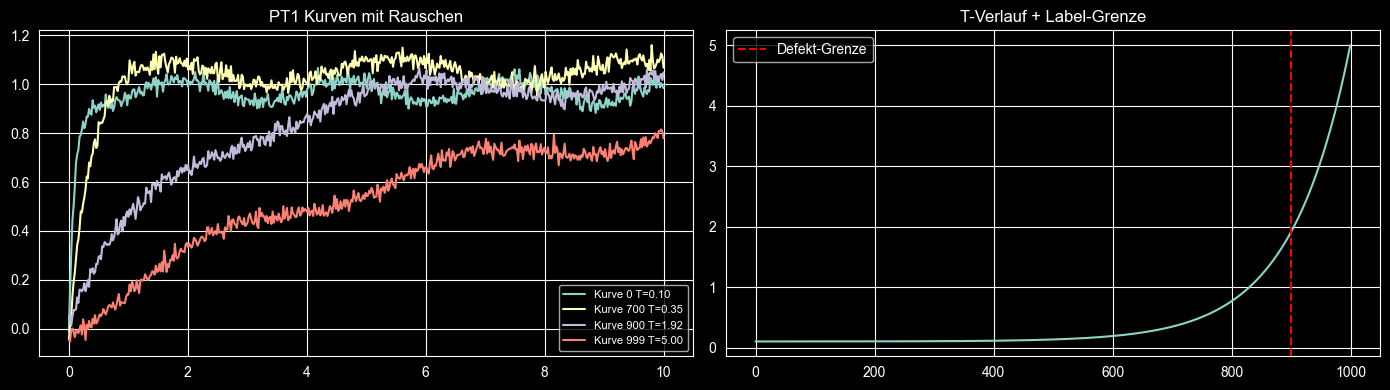

In [22]:
np.random.seed(42)                          # Zufallsgenerator fixieren – wie 'rng(42)' in MATLAB, damit Ergebnisse reproduzierbar sind

n_curves = 1000                             # Anzahl der PT1-Kurven – normale Variablenzuweisung (kein Semikolon nötig wie in MATLAB)
t = np.linspace(0, 10, 500)                # Zeitachse von 0 bis 10 mit 500 Punkten – identisch zu MATLAB's linspace(0,10,500)
SEQ_LEN = len(t)                           # Sequenzlänge = 500 – wird später für Modell und Test-Zellen gebraucht

T_min = 0.1                                # kleinste Zeitkonstante T (gesunder Schalter)
T_max = 5.0                                # größte Zeitkonstante T (defekter Schalter)
K = 1.0                                    # Verstärkungsfaktor der PT1-Kurve

x = np.linspace(0, 1, n_curves)            # 1000 gleichmäßige Werte von 0 bis 1 – Hilfsvektor für die T-Verteilung
steepness = 10                             # Steilheit der Exponentialverteilung – je größer, desto mehr Kurven liegen im gesunden Bereich
T_norm = (np.exp(steepness * x) - 1) / (np.exp(steepness) - 1)  # normierter T-Verlauf 0→1, exponentiell verteilt (wie in MATLAB: exp(...))
T_values = T_min + T_norm * (T_max - T_min)  # T-Werte skalieren: von T_min bis T_max – wie MATLAB: T_min + T_norm * (T_max - T_min)

def add_distortions(signal, t, noise_std=0.02, drift_amp=0.05, amplitude_jitter=0.1):  # 'def' definiert eine Funktion – wie 'function y = f(x)' in MATLAB
    """Rauschen, Baseline-Drift und Amplitudenverzerrung."""                           # Dokumentationsstring der Funktion (optional, aber guter Stil)
    noisy = signal + np.random.normal(0, noise_std, len(signal))  # Gauß'sches Rauschen addieren – wie signal + noise_std*randn(1,N) in MATLAB
    drift_freq = np.random.uniform(0.1, 0.5)                      # zufällige Driftfrequenz zwischen 0.1 und 0.5 Hz
    drift_phase = np.random.uniform(0, 2 * np.pi)                 # zufällige Phase zwischen 0 und 2π – np.pi ist wie pi in MATLAB
    drift = drift_amp * np.sin(2 * np.pi * drift_freq * t + drift_phase)  # Sinusförmige Baseline-Drift – wie in MATLAB: A*sin(2*pi*f*t + phi)
    noisy += drift                                                 # '+=' ist Kurzform für: noisy = noisy + drift
    amp_factor = 1.0 + np.random.uniform(-amplitude_jitter, amplitude_jitter)  # zufälliger Skalierungsfaktor z.B. zwischen 0.9 und 1.1
    noisy *= amp_factor                                            # '*=' ist Kurzform für: noisy = noisy * amp_factor – skaliert die ganze Kurve
    return noisy                                                   # Rückgabe des verzerrten Signals – wie in MATLAB 'y = noisy;' am Ende

dataset = np.zeros((n_curves, len(t)))     # leere Matrix anlegen: 1000 Zeilen, 500 Spalten – wie zeros(1000, 500) in MATLAB
labels = np.zeros(n_curves, dtype=int)     # Labels-Vektor mit 1000 Nullen (dtype=int bedeutet ganzzahlig, nicht float)

for i, T in enumerate(T_values):           # Schleife über alle T-Werte; 'enumerate' liefert Index i UND Wert T gleichzeitig – in MATLAB wäre es: for i=1:N, T=T_values(i)
    clean = K * (1 - np.exp(-t / T))       # saubere PT1-Kurve berechnen – identisch zur MATLAB-Formel K*(1-exp(-t/T))
    dataset[i] = add_distortions(clean, t) # verzerrte Kurve in Zeile i speichern – in MATLAB: dataset(i,:) = ...
    labels[i] = 1 if i >= 900 else 0       # Ternärer Ausdruck: wenn i>=900 dann 1, sonst 0 – in MATLAB: if i>=900; labels(i)=1; else; labels(i)=0; end

print(f"Dataset Shape: {dataset.shape}")  # f-String: Variable in {} wird direkt eingesetzt – wie disp(['Shape: ' num2str(...)]) in MATLAB
print(f"Labels: {np.sum(labels == 0)} gesund, {np.sum(labels == 1)} defekt")  # np.sum zählt True-Werte – wie sum(labels==0) in MATLAB

fig, axes = plt.subplots(1, 2, figsize=(14, 4))  # Figure mit 1 Zeile, 2 Spalten Subplots – wie subplot(1,2,...) in MATLAB; fig=Figure-Objekt, axes=Array der Achsen
for idx, label in [(0, 'gesund (0)'), (700, 'gesund (700)'), (900, 'defekt (900)'), (999, 'defekt (999)')]:  # Liste von Tupeln: (index, beschriftung)
    axes[0].plot(t, dataset[idx], label=f'Kurve {idx} T={T_values[idx]:.2f}')  # in den linken Subplot plotten; :.2f = 2 Dezimalstellen
axes[0].set_title('PT1 Kurven mit Rauschen')  # Titel setzen – wie title('...') in MATLAB
axes[0].legend(fontsize=8)                    # Legende anzeigen – wie legend() in MATLAB
axes[0].grid(True)                            # Gitternetz aktivieren – wie grid on in MATLAB

axes[1].plot(T_values)                        # T-Verlauf in rechten Subplot plotten
axes[1].axvline(x=900, color='red', linestyle='--', label='Defekt-Grenze')  # vertikale Linie bei x=900 – wie xline(900) in MATLAB
axes[1].set_title('T-Verlauf + Label-Grenze') # Titel für rechten Subplot
axes[1].legend()                              # Legende anzeigen
axes[1].grid(True)                            # Gitternetz aktivieren
plt.tight_layout()                            # Abstände zwischen Subplots automatisch anpassen
plt.show()                                    # Figure anzeigen – in MATLAB passiert das automatisch, hier muss man es explizit aufrufen

## Schritt 2: Dataset & DataLoader

In [23]:
data_min = dataset.min(axis=1, keepdims=True)   # Minimum jeder Zeile (Kurve) – axis=1 bedeutet: über Spalten, also pro Kurve; keepdims behält die Form (1000,1)
data_max = dataset.max(axis=1, keepdims=True)   # Maximum jeder Zeile – wie min(dataset,[],2) in MATLAB
dataset_norm = (dataset - data_min) / (data_max - data_min + 1e-8)  # Min-Max-Normalisierung auf [0,1]; +1e-8 verhindert Division durch Null

X_train, X_test, y_train, y_test = train_test_split(  # Aufteilung in Trainings- und Testdaten
    dataset_norm, labels,       # Eingabedaten und zugehörige Labels
    test_size=0.2,              # 20% der Daten gehen ins Test-Set
    random_state=42,            # Zufalls-Seed für Reproduzierbarkeit
    stratify=labels             # stellt sicher dass beide Klassen proportional verteilt sind (nicht alle Defekte landen im Test)
)

class CurveDataset(Dataset):    # 'class' definiert eine Klasse – wie eine Struktur in MATLAB aber mit Methoden; 'Dataset' ist die Elternklasse von PyTorch
    def __init__(self, X, y):   # Konstruktor – wird aufgerufen wenn man CurveDataset(...) schreibt; 'self' ist der Verweis auf das Objekt selbst
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # Array → PyTorch-Tensor (float32); unsqueeze(-1) fügt letzte Dimension hinzu: (1000,500) → (1000,500,1)
        self.y = torch.tensor(y, dtype=torch.long)                    # Labels als ganzzahlige Tensor (long = int64) – nötig für CrossEntropyLoss

    def __len__(self):          # Methode die die Länge des Datasets zurückgibt – PyTorch ruft das intern auf
        return len(self.y)      # gibt Anzahl der Samples zurück

    def __getitem__(self, idx): # Methode für Zugriff per Index – PyTorch ruft das auf wenn es ein Sample holen will (wie dataset[i] in MATLAB)
        return self.X[idx], self.y[idx]  # gibt Kurve und Label als Tupel zurück

train_loader = DataLoader(CurveDataset(X_train, y_train), batch_size=32, shuffle=True)   # DataLoader liefert automatisch Batches; shuffle=True mischt die Daten vor jeder Epoche
test_loader  = DataLoader(CurveDataset(X_test,  y_test),  batch_size=64, shuffle=False)  # Test-Daten nicht mischen (Reihenfolge für Auswertung egal, aber kein Mischen nötig)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")                          # Anzahl der Samples ausgeben
print(f"Input shape pro Batch: {next(iter(train_loader))[0].shape}")           # iter(...) macht den DataLoader iterierbar; next(...) holt den ersten Batch; [0] = X, [1] = y

Train: 800, Test: 200
Input shape pro Batch: torch.Size([32, 500, 1])


## Schritt 3: Transformer Modell

In [24]:
class PositionalEncoding(nn.Module):         # Klasse für Positional Encoding – erbt von nn.Module (Basisklasse für alle PyTorch-Modelle)
    def __init__(self, d_model, max_len=500): # Konstruktor; d_model = Vektordimension; max_len = maximale Sequenzlänge
        super().__init__()                    # Elternklasse initialisieren – muss immer am Anfang stehen
        pe = torch.zeros(max_len, d_model)   # leere Matrix: (500, 64) – wird mit Sinus/Kosinus-Werten gefüllt
        pos = torch.arange(0, max_len).unsqueeze(1).float()  # Positionen 0,1,...,499 als Spaltenvektor (500,1); .float() = float32
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))  # Frequenzfaktoren für die Sinus/Kosinus-Formeln
        pe[:, 0::2] = torch.sin(pos * div)   # gerade Spalten (0,2,4,...) mit Sinus füllen; 0::2 bedeutet: von 0 bis Ende, Schrittweite 2 – wie 1:2:end in MATLAB
        pe[:, 1::2] = torch.cos(pos * div)   # ungerade Spalten (1,3,5,...) mit Kosinus füllen
        self.register_buffer('pe', pe.unsqueeze(0))  # pe als festen Buffer speichern (kein trainierbarer Parameter); unsqueeze(0) → (1,500,64)

    def forward(self, x):                    # 'forward' definiert was passiert wenn das Modell aufgerufen wird – wie der Funktionskörper in MATLAB
        return x + self.pe[:, :x.size(1)]   # Positionsinformation zum Input addieren; x.size(1) = Sequenzlänge des aktuellen Batches


class CircuitBreakerTransformer(nn.Module): # Hauptmodell – erbt ebenfalls von nn.Module
    def __init__(self, seq_len=500, d_model=64, nhead=4, num_layers=2, dropout=0.1):  # Hyperparameter als Argumente mit Standardwerten
        super().__init__()                   # Elternklasse initialisieren
        self.input_proj = nn.Linear(1, d_model)  # Lineare Schicht: 1 Feature → 64 Dimensionen – wie eine Gewichtsmatrix W in MATLAB (y = W*x)
        self.pos_enc = PositionalEncoding(d_model, max_len=seq_len)  # Positional-Encoding-Objekt erstellen (oben definierte Klasse)
        encoder_layer = nn.TransformerEncoderLayer(  # ein einzelner Transformer-Block (Self-Attention + FFN)
            d_model=d_model,        # Vektordimension
            nhead=nhead,            # Anzahl der Attention-Heads (4 parallele Attention-Mechanismen)
            dim_feedforward=128,    # Größe des inneren Feed-Forward-Netzes
            dropout=dropout,        # Dropout-Rate: 10% der Neuronen werden zufällig deaktiviert (verhindert Overfitting)
            batch_first=True        # Input-Format: (batch, seq, features) statt (seq, batch, features)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)  # stapelt num_layers=2 Encoder-Blöcke übereinander
        self.classifier = nn.Sequential(     # nn.Sequential = mehrere Layer hintereinander – wie eine Pipeline
            nn.Linear(d_model, 32),          # erste lineare Schicht: 64 → 32 Neuronen
            nn.ReLU(),                       # Aktivierungsfunktion: max(0, x) – macht das Netz nichtlinear
            nn.Dropout(dropout),             # Dropout zur Regularisierung
            nn.Linear(32, 2)                 # Ausgabeschicht: 32 → 2 (eine Zahl pro Klasse: gesund / defekt)
        )

    def forward(self, x):                    # Vorwärtsdurchlauf: definiert wie Daten durch das Modell fließen
        x = self.input_proj(x)               # (batch, 500, 1) → (batch, 500, 64) – Projektion in höherdimensionalen Raum
        x = self.pos_enc(x)                  # Positionsinformation addieren – Transformer weiß jetzt wo in der Sequenz jeder Wert liegt
        x = self.transformer(x)              # durch die Transformer-Encoder-Blöcke – (batch, 500, 64) bleibt gleiche Form
        x = x.mean(dim=1)                    # Global Average Pooling: Mittelwert über alle 500 Zeitschritte → (batch, 64); dim=1 = über Sequenz-Dimension
        return self.classifier(x)            # Klassifikations-Kopf: (batch, 64) → (batch, 2) – zwei Rohwerte (Logits) pro Sample


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # GPU nehmen falls vorhanden, sonst CPU – in MATLAB gibt es das nicht
model = CircuitBreakerTransformer().to(device)  # Modell erstellen und auf das gewählte Gerät (GPU/CPU) verschieben
print(model)                                    # Modellarchitektur ausgeben
print(f"\nParameter: {sum(p.numel() for p in model.parameters()):,}")  # Gesamtzahl der Gewichte zählen; :, formatiert mit Tausenderpunkt
print(f"Device: {device}")                      # ausgeben ob GPU oder CPU verwendet wird

CircuitBreakerTransformer(
  (input_proj): Linear(in_features=1, out_features=64, bias=True)
  (pos_enc): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features

## Schritt 4: Training

In [25]:
# criterion = nn.CrossEntropyLoss()              # Loss-Funktion für Klassifikation – misst wie falsch die Vorhersagen sind; kein MATLAB-Äquivalent direkt
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # Adam-Optimierer: passt Gewichte an um Loss zu minimieren; lr=Lernrate (wie Schrittweite)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)  # Lernrate alle 10 Epochen halbieren – verhindert Überschießen am Ende
#
# def train_epoch(model, loader):                # Funktion für eine Trainings-Epoche (ein kompletter Durchlauf aller Trainingsdaten)
#     model.train()                              # Modell in Trainings-Modus schalten (aktiviert Dropout usw.)
#     total_loss, correct = 0, 0                 # Mehrfachzuweisung: beide Variablen auf 0 setzen – in MATLAB: total_loss=0; correct=0;
#     for X, y in loader:                        # Schleife über alle Batches; loader gibt automatisch (X, y)-Paare raus
#         X, y = X.to(device), y.to(device)     # Daten auf GPU/CPU verschieben – Modell und Daten müssen auf demselben Gerät sein
#         optimizer.zero_grad()                  # Gradienten aus letztem Schritt löschen – muss jedes Mal gemacht werden (PyTorch akkumuliert sonst)
#         out = model(X)                         # Vorwärtsdurchlauf: Eingabe durch Modell schicken → Logits (Rohwerte)
#         loss = criterion(out, y)               # Loss berechnen: wie weit liegen Vorhersagen von wahren Labels entfernt
#         loss.backward()                        # Rückwärtsdurchlauf: Gradienten berechnen (Backpropagation) – automatisch, kein manuelles Ableiten
#         optimizer.step()                       # Gewichte aktualisieren basierend auf den Gradienten
#         total_loss += loss.item() * len(y)     # .item() holt den Python-Zahlenwert aus dem Tensor; Gewichtung mit Batchgröße für korrekten Durchschnitt
#         correct += (out.argmax(1) == y).sum().item()  # argmax(1) = Index der größten Klassen-Zahl (0 oder 1); zählt korrekte Vorhersagen
#     return total_loss / len(loader.dataset), correct / len(loader.dataset)  # durchschnittlicher Loss und Accuracy zurückgeben
#
# @torch.no_grad()                               # Dekorator: innerhalb dieser Funktion keine Gradienten berechnen (spart Speicher und Zeit)
# def eval_epoch(model, loader):                 # Funktion für Auswertung auf Test-Daten
#     model.eval()                               # Modell in Auswertungs-Modus schalten (deaktiviert Dropout)
#     total_loss, correct = 0, 0                 # Zähler zurücksetzen
#     for X, y in loader:                        # Schleife über Test-Batches
#         X, y = X.to(device), y.to(device)     # auf Gerät verschieben
#         out = model(X)                         # Vorwärtsdurchlauf (kein backward, da @no_grad)
#         total_loss += criterion(out, y).item() * len(y)  # Loss aufaddieren
#         correct += (out.argmax(1) == y).sum().item()      # korrekte Vorhersagen zählen
#     return total_loss / len(loader.dataset), correct / len(loader.dataset)  # Loss und Accuracy zurückgeben
#
# n_epochs = 30                                  # Anzahl der Trainingsepochen – wie oft der Optimierer alle Daten sieht
# history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}  # Dictionary (wie struct in MATLAB) zum Speichern der Verläufe; [] = leere Liste
#
# for epoch in range(1, n_epochs + 1):           # Schleife von 1 bis 30 – range(1, 31) erzeugt 1,2,...,30; in MATLAB: for epoch=1:30
#     tr_loss, tr_acc = train_epoch(model, train_loader)  # eine Trainingsepoche ausführen, Loss und Accuracy holen
#     va_loss, va_acc = eval_epoch(model, test_loader)    # eine Auswertungsepoche auf Test-Daten
#     scheduler.step()                           # Lernrate-Scheduler einen Schritt weiter – prüft ob Lernrate reduziert werden soll
#     history['train_loss'].append(tr_loss)      # .append() fügt Element ans Ende einer Liste – wie history.train_loss(end+1) in MATLAB
#     history['train_acc'].append(tr_acc)        # Trainings-Accuracy speichern
#     history['val_loss'].append(va_loss)        # Validierungs-Loss speichern
#     history['val_acc'].append(va_acc)          # Validierungs-Accuracy speichern
#     if epoch % 5 == 0:                         # % ist Modulo – 'epoch % 5 == 0' ist True wenn epoch durch 5 teilbar (5,10,15,...)
#         print(f"Epoch {epoch:02d} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | Val Loss: {va_loss:.4f} Acc: {va_acc:.3f}")  # :02d = mindestens 2 Stellen, führende Null; :.4f = 4 Dezimalstellen

## Modell speichern / laden
**Nach dem Training:** Die "Speichern"-Zelle ausführen.  
**Beim nächsten Start:** Nur Zellen 1–3 (Imports + Klassen) ausführen, dann die "Laden"-Zelle – Training überspringen.

In [26]:
# ── Modell SPEICHERN (nach dem Training einmal ausführen) ──────────────────
torch.save({
    'model_state_dict': model.state_dict(),
    'SEQ_LEN': SEQ_LEN,
}, 'circuit_breaker_model.pth')

np.save('dataset_norm.npy', dataset_norm)  # alle 1000 Kurven speichern
np.save('labels.npy', labels)

print("Modell und Datensatz gespeichert!")

Modell und Datensatz gespeichert!


In [27]:
# ── Modell LADEN (statt Training – Zellen 1-3 vorher ausführen!) ───────────
checkpoint = torch.load('circuit_breaker_model.pth', weights_only=True)
SEQ_LEN = checkpoint['SEQ_LEN']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CircuitBreakerTransformer(seq_len=SEQ_LEN).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

dataset_norm = np.load('dataset_norm.npy')  # alle 1000 Kurven laden
labels = np.load('labels.npy')

print(f"Modell geladen! SEQ_LEN={SEQ_LEN}, Kurven={len(dataset_norm)}, Device={device}")

Modell geladen! SEQ_LEN=500, Kurven=1000, Device=cpu


## Schritt 5: Auswertung

In [28]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Figure mit 2 Subplots nebeneinander – wie figure; subplot(1,2,1) in MATLAB
# axes[0].plot(history['train_loss'], label='Train')  # Trainings-Loss über Epochen plotten; history['train_loss'] ist die Liste der gespeicherten Werte
# axes[0].plot(history['val_loss'], label='Val')      # Validierungs-Loss in denselben Subplot
# axes[0].set_title('Loss')                           # Titel setzen
# axes[0].legend()                                    # Legende anzeigen
# axes[0].grid(True)                                  # Gitternetz
#
# axes[1].plot(history['train_acc'], label='Train')   # Trainings-Accuracy plotten
# axes[1].plot(history['val_acc'], label='Val')       # Validierungs-Accuracy plotten
# axes[1].set_title('Accuracy')                       # Titel
# axes[1].legend()                                    # Legende
# axes[1].grid(True)                                  # Gitternetz
# plt.tight_layout()                                  # Layout automatisch anpassen
# plt.show()                                          # Figure anzeigen
#
# model.eval()                                        # Modell in Auswertungs-Modus (Dropout aus)
# all_preds, all_labels = [], []                      # leere Listen für alle Vorhersagen und echten Labels
# with torch.no_grad():                               # 'with'-Block: alles darin läuft ohne Gradienten-Berechnung – spart Speicher
#     for X, y in test_loader:                        # alle Test-Batches durchlaufen
#         preds = model(X.to(device)).argmax(1).cpu().numpy()  # Vorhersage: argmax gibt 0 oder 1; .cpu() zurück auf CPU; .numpy() → NumPy-Array
#         all_preds.extend(preds)                     # .extend() fügt alle Elemente einer Liste hinzu (nicht die Liste selbst wie append)
#         all_labels.extend(y.numpy())                # echte Labels ebenfalls sammeln
#
# print(classification_report(all_labels, all_preds, target_names=['gesund', 'defekt']))  # detaillierter Bericht: Precision, Recall, F1 pro Klasse
#
# cm = confusion_matrix(all_labels, all_preds)  # Konfusionsmatrix berechnen: Zeilen=echte Klasse, Spalten=vorhergesagte Klasse
# plt.figure(figsize=(5, 4))                    # neue Figure erstellen
# sns.heatmap(cm, annot=True, fmt='d',          # Heatmap zeichnen; annot=True zeigt Zahlen; fmt='d' = ganzzahlig
#             cmap='Blues',                     # Farbschema
#             xticklabels=['gesund', 'defekt'], # Beschriftung X-Achse
#             yticklabels=['gesund', 'defekt']) # Beschriftung Y-Achse
# plt.title('Confusion Matrix')                 # Titel
# plt.ylabel('True')                            # Y-Achsen-Beschriftung: echte Klasse
# plt.xlabel('Predicted')                       # X-Achsen-Beschriftung: vorhergesagte Klasse
# plt.tight_layout()                            # Layout anpassen
# plt.show()                                    # anzeigen

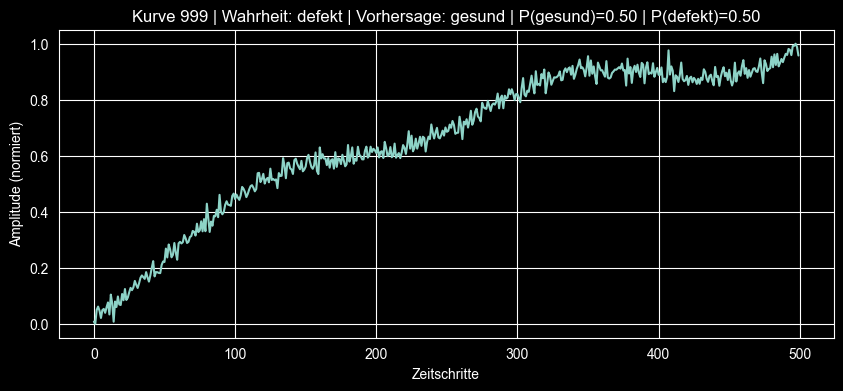

In [29]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt

# ── Modell-Klassen ──────────────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class CircuitBreakerTransformer(nn.Module):
    def __init__(self, seq_len=500, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=seq_len)
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)
        self.classifier = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 2))
    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.transformer(x)
        return self.classifier(x.mean(dim=1))

# ── Index auswählen ─────────────────────────────────────────────────────────
idx = 999  # ← hier ändern (0–999) | 0-899 = gesund, 900-999 = defekt

# ── Modell & Daten laden ────────────────────────────────────────────────────
checkpoint = torch.load('circuit_breaker_model.pth', weights_only=True)
SEQ_LEN = checkpoint['SEQ_LEN']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CircuitBreakerTransformer(seq_len=SEQ_LEN).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

dataset_norm = np.load('dataset_norm.npy')
labels = np.load('labels.npy')

# ── Vorhersage ──────────────────────────────────────────────────────────────
kurve = dataset_norm[idx].reshape(1, SEQ_LEN, 1)
with torch.no_grad():
    prob = torch.softmax(model(torch.tensor(kurve, dtype=torch.float32).to(device)), dim=1).cpu().numpy()[0]
pred = np.argmax(prob)

label_names = {0: "gesund", 1: "defekt"}
plt.figure(figsize=(10, 4))
plt.plot(dataset_norm[idx])
plt.title(f"Kurve {idx} | Wahrheit: {label_names[labels[idx]]} | Vorhersage: {label_names[pred]} | "
          f"P(gesund)={prob[0]:.2f} | P(defekt)={prob[1]:.2f}")
plt.xlabel("Zeitschritte")
plt.ylabel("Amplitude (normiert)")
plt.grid(True)
plt.show()